In [2]:
using JLD2
using Plots
using Statistics
using Printf

gr()


Plots.GRBackend()

In [3]:
cutoffs = ["1.0e-4", "1.0e-5", "1.0e-6", "1.0e-7", "1.0e-8", "1.0e-9", "1.0e-10", "1.0e-11", "1.0e-12", "1.0e-13", "1.0e-14"]
sigma_list = [0.2, 0.02, 0.002, 0.0002, 0.0]
sigma_list_small = [0.02, 0.002, 0.0002, 0.0]




data_dict = Dict()
results = Dict()

for c in cutoffs
    filename = joinpath(@__DIR__, "truncation_$(c).jld2")
    
    if isfile(filename)
        data = JLD2.load(filename)
        data_dict[c] = data
        
        results[c] = data["entanglement_results"]
        var_name = "results_" * replace(c, "-" => "_", "." => "_")
        eval(:($(Symbol(var_name)) = $(results[c])))
        
    else
        println("Warning: File $filename not found.")
    end
end

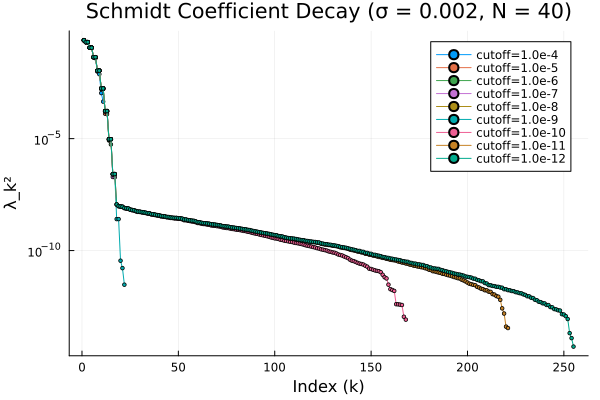

In [4]:
"""
Plots the Schmidt coefficients (Entanglement Spectrum) on a log scale 
for a specific sigma and N across all truncation cutoffs.
"""
function plot_schmidt_truncation_comparison(target_sigma, target_N, results_dict, cutoffs_list)
    p = plot(
        title="Schmidt Coefficient Decay (σ = $target_sigma, N = $target_N)",
        xlabel="Index (k)",
        ylabel="λ_k²",
        yaxis=:log10,
        legend=:topright,
        grid=true,
        lw=2
    )


    
    for c in cutoffs_list
        if haskey(results_dict, c) && haskey(results_dict[c], target_sigma)
            sigma_data = results_dict[c][target_sigma]
            
            if haskey(sigma_data, target_N)
                coeffs = sigma_data[target_N] .^2
                
                valid_indices = findall(x -> x > 1e-20, coeffs)
                
                plot!(
                    p, 
                    valid_indices, 
                    coeffs[valid_indices], 
                    label="cutoff=$c", 
                    marker=:circle, 
                    markersize=2,
                    alpha=1
                )
            end
        end
    end
    return p
end

p_schmidt = plot_schmidt_truncation_comparison(0.002, 40, results, cutoffs)

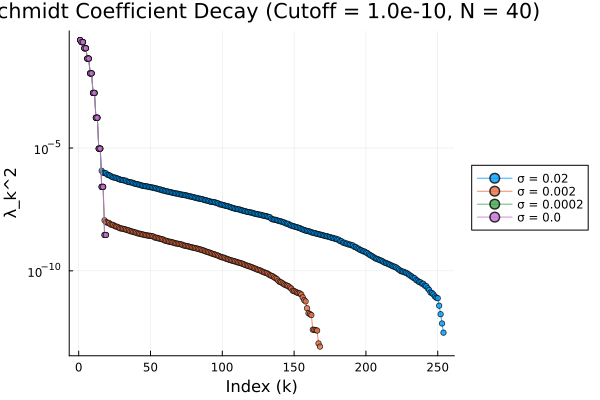

In [5]:
"""
Plots the Schmidt coefficients (Entanglement Spectrum) on a log scale 
for all available sigma values at a specific N and a chosen truncation cutoff.
"""
function plot_schmidt_sigma_comparison(target_cutoff, target_N, results_dict)
    if !haskey(results_dict, target_cutoff)
        println("Error: Cutoff $target_cutoff not found in results.")
        return nothing
    end

    p = plot(
        title="Schmidt Coefficient Decay (Cutoff = $target_cutoff, N = $target_N)",
        xlabel="Index (k)",
        ylabel="λ_k^2",
        yaxis=:log10,
        legend=:outerright,
        grid=true,
        lw=2
    )

    # Get all sigma values for this specific cutoff and sort them
    sigmas = sort(collect(keys(results_dict[target_cutoff])), rev = true)
    sigma_list_small = [0.02, 0.002, 0.0002, 0.0]


    for σ in sigma_list_small
        sigma_data = results_dict[target_cutoff][σ]
        
        if haskey(sigma_data, target_N)
            coeffs = sigma_data[target_N]
            
            # Filter out very small values to keep the log plot clean
            valid_indices = findall(x -> x > 1e-20, coeffs)
            
            plot!(
                p, 
                valid_indices, 
                coeffs[valid_indices].^2, 
                label="σ = $σ", 
                marker=:circle, 
                markersize=3,
                alpha=0.8
            )
        end
    end
    return p
end


p_sigma_comp = plot_schmidt_sigma_comparison("1.0e-10", 40, results)

In [6]:
function renyi_entropy(coeffs, α)
    probs = coeffs .^ 2
    # Filter for numerical stability (avoid log(0))
    probs = probs[probs .> 1e-30]
    
    if α == 1.0
        return -sum(probs .* log.(probs))
    elseif α == 0.0
        return log(length(probs))
    elseif α == Inf
        return -log(maximum(probs))
    else
        return (1 / (1 - α)) * log(sum(probs .^ α))
    end
end

# Generalised plotting function
function plot_entropy_task(target_sigma, results_dict, cutoffs_list, α, title_str, ylabel_str)
    p = plot(title="$title_str (σ = $target_sigma)", 
             xlabel="System Size (N)", ylabel=ylabel_str,
             legend=:outerright, grid=true, lw=1.5)

    for c in cutoffs_list
        haskey(results_dict, c) || continue
        haskey(results_dict[c], target_sigma) || continue
        
        sigma_data = results_dict[c][target_sigma]
        sorted_Ns = sort(collect(keys(sigma_data)))
        
        # Optimised map: applies renyi_entropy to each N's vector
        values = [renyi_entropy(sigma_data[n], α) for n in sorted_Ns]
        
        plot!(p, sorted_Ns, values, label="cutoff=$c", marker=:circle, markersize=3)
    end
    return p
end



plot_entropy_task (generic function with 1 method)

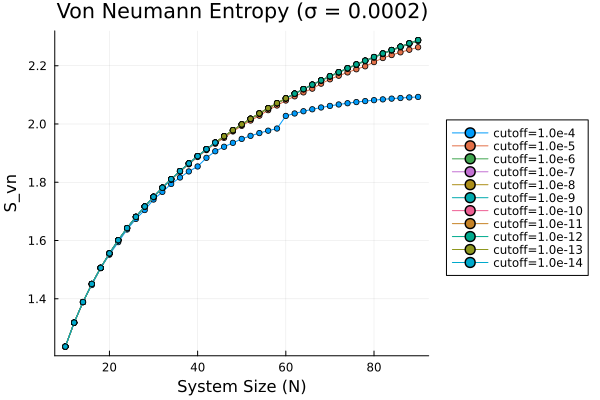

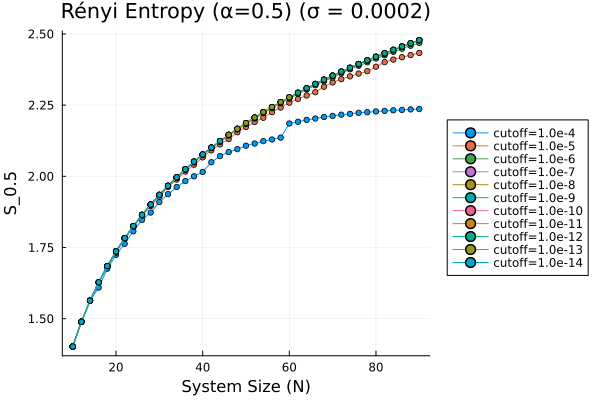

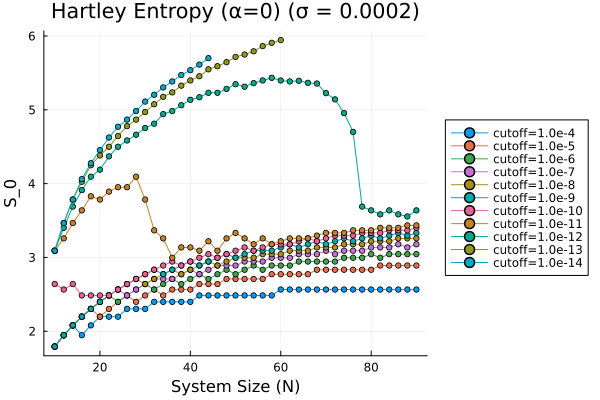

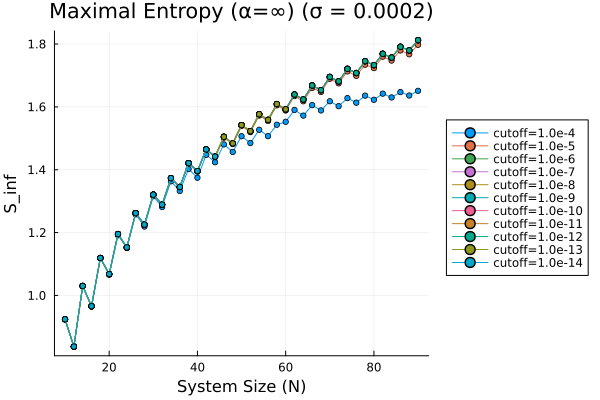

In [7]:
entropy_sigma = 0.0002


function plot_von_neumann(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, 1.0, "Von Neumann Entropy", "S_vn")
end
p_vn = plot_von_neumann(entropy_sigma, results, cutoffs)
display(p_vn)



function plot_renyi_05(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, 0.5, "Rényi Entropy (α=0.5)", "S_0.5")
end
p_r05 = plot_renyi_05(entropy_sigma, results, cutoffs)
display(p_r05)



function plot_hartley(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, 0.0, "Hartley Entropy (α=0)", "S_0")
end
p_hartley = plot_hartley(entropy_sigma, results, cutoffs)
display(p_hartley)



function plot_maximal(σ, res, cuts)
    plot_entropy_task(σ, res, cuts, Inf, "Maximal Entropy (α=∞)", "S_inf")
end
p_max = plot_maximal(entropy_sigma, results, cutoffs)
display(p_max)

In [8]:
function calculate_renyi(coeffs, α)

    probs = @views coeffs .^ 2
    probs = probs[probs .> 1e-30]
    
    if α == 1.0      # Von Neumann
        return -sum(probs .* log.(probs))
    elseif α == 0.0  # Hartley
        return log(length(probs))
    elseif α == Inf  # Maximal
        return -log(maximum(probs))
    else             # General Renyi (e.g. 0.5)
        return (1 / (1 - α)) * log(sum(probs .^ α))
    end
end

function plot_entropy_all_sigmas_task(target_cutoff, results_dict, α, title_str, ylabel_str)
    # Validate cutoff
    !haskey(results_dict, target_cutoff) && return println("Error: Cutoff $target_cutoff not found.")
    
    p = plot(title="$title_str (Truncation: $target_cutoff)", 
             xlabel="System Size (N)", ylabel=ylabel_str,
             legend=:outerright, grid=true, lw=1.5)

    # Automatically get and sort all available sigma values
    sigmas = sort(collect(keys(results_dict[target_cutoff])))

    for σ in sigmas
        sigma_data = results_dict[target_cutoff][σ]
        sorted_Ns = sort(collect(keys(sigma_data)))
        
        values = [calculate_renyi(sigma_data[n], α) for n in sorted_Ns]
        
        plot!(p, sorted_Ns, values, label="σ=$σ", marker=:circle, markersize=3)
    end
    return p
end

plot_entropy_all_sigmas_task (generic function with 1 method)

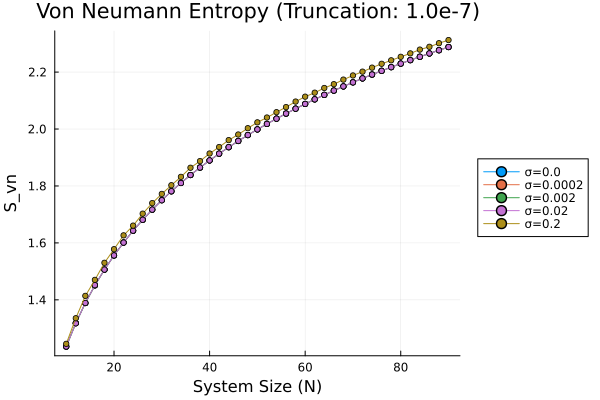

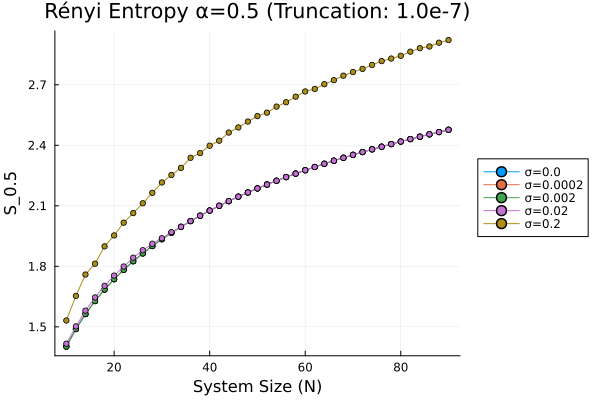

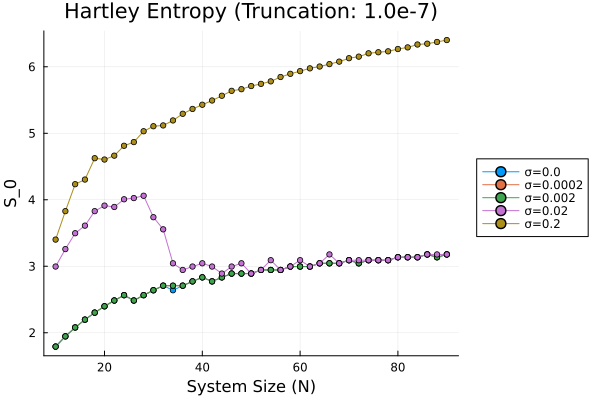

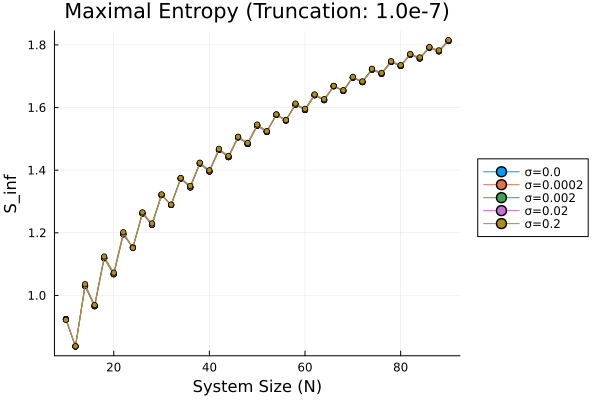

In [9]:
entropy_cutoff = "1.0e-7"

function plot_von_neumann_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, 1.0, "Von Neumann Entropy", "S_vn")
end
p_vn_sigmas = plot_von_neumann_sigmas(entropy_cutoff, results)
display(p_vn_sigmas)



function plot_renyi_05_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, 0.5, "Rényi Entropy α=0.5", "S_0.5")
end
p_r05_sigmas = plot_renyi_05_sigmas(entropy_cutoff, results)
display(p_r05_sigmas)



function plot_hartley_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, 0.0, "Hartley Entropy", "S_0")
end
p_hart_sigmas = plot_hartley_sigmas(entropy_cutoff, results)
display(p_hart_sigmas)



function plot_maximal_sigmas(cutoff, res)
    plot_entropy_all_sigmas_task(cutoff, res, Inf, "Maximal Entropy", "S_inf")
end
p_max_sigmas = plot_maximal_sigmas(entropy_cutoff, results)
display(p_max_sigmas)

In [10]:
"""
Calculates the deviation index for EVERY truncation and EVERY sigma.
Returns a dictionary structured as: [cutoff][sigma][N] -> dev_index
"""
function calc_deviation_indices(results_all::Dict; threshold=0.1, N_subset=nothing)
    dev_dict = Dict()

    for target_cutoff in keys(results_all)
        cutoff_data = results_all[target_cutoff]
        
        # Check if we have a σ=0.0 reference for this specific cutoff
        if !haskey(cutoff_data, 0.0)
            @warn "No σ=0.0 reference found for cutoff $target_cutoff. Skipping."
            continue
        end
        
        results_clean = cutoff_data[0.0]
        all_sigma_deviations = Dict{Float64, Dict{Int, Int}}()
        
        for σ in keys(cutoff_data)
            # skip 0.0 because it is the reference 
            σ == 0.0 && continue
            
            results_disordered = cutoff_data[σ]
            deviation_indices = Dict{Int, Int}()
            
            # Use intersection of Ns to avoid KeyErrors
            available_Ns = intersect(keys(results_clean), keys(results_disordered))
            if N_subset !== nothing
                available_Ns = intersect(available_Ns, N_subset)
            end
            
            for N in sort(collect(available_Ns))
                v_clean = sort(results_clean[N], rev=true)
                v_disorder = sort(results_disordered[N], rev=true)
                
                min_len = min(length(v_clean), length(v_disorder))
                dev_idx = min_len 
                
                for i in 1:min_len
                    val_c = v_clean[i].^2
                    val_d = v_disorder[i].^2
                    
                    if val_c < 1e-16 || val_d < 1e-16
                        if abs(val_c - val_d) > 1e-10
                            dev_idx = i
                            break
                        end
                        continue
                    end
                    
                    if (abs(val_c - val_d) / max(val_c, val_d)) > threshold
                        dev_idx = i
                        break
                    end
                end
                deviation_indices[N] = dev_idx
            end
            all_sigma_deviations[σ] = deviation_indices
        end
        dev_dict[target_cutoff] = all_sigma_deviations
    end
    
    return dev_dict
end

deviation_indices = calc_deviation_indices(results, threshold=0.0005)

Dict{Any, Any} with 11 entries:
  "1.0e-7"  => Dict(0.002=>Dict(78=>22, 56=>18, 16=>8, 20=>10, 58=>20, 52=>18, …
  "1.0e-6"  => Dict(0.002=>Dict(78=>20, 56=>17, 16=>8, 20=>10, 58=>18, 52=>17, …
  "1.0e-4"  => Dict(0.002=>Dict(78=>13, 56=>12, 16=>7, 20=>9, 58=>12, 52=>12, 6…
  "1.0e-13" => Dict(0.0002=>Dict(56=>24, 16=>9, 20=>11, 58=>25, 52=>23, 60=>24,…
  "1.0e-10" => Dict(0.002=>Dict(78=>22, 56=>20, 16=>8, 20=>10, 58=>19, 52=>18, …
  "1.0e-9"  => Dict(0.002=>Dict(78=>23, 56=>19, 16=>8, 20=>10, 58=>19, 52=>18, …
  "1.0e-8"  => Dict(0.002=>Dict(78=>22, 56=>18, 16=>8, 20=>10, 58=>20, 52=>16, …
  "1.0e-12" => Dict(0.002=>Dict(56=>22, 16=>8, 20=>10, 58=>23, 52=>22, 60=>22, …
  "1.0e-14" => Dict(0.0002=>Dict(16=>9, 20=>11, 12=>7, 24=>13, 28=>15, 30=>16, …
  "1.0e-5"  => Dict(0.002=>Dict(78=>17, 56=>15, 16=>8, 20=>9, 58=>16, 52=>15, 6…
  "1.0e-11" => Dict(0.002=>Dict(78=>23, 56=>22, 16=>8, 20=>10, 58=>21, 52=>21, …

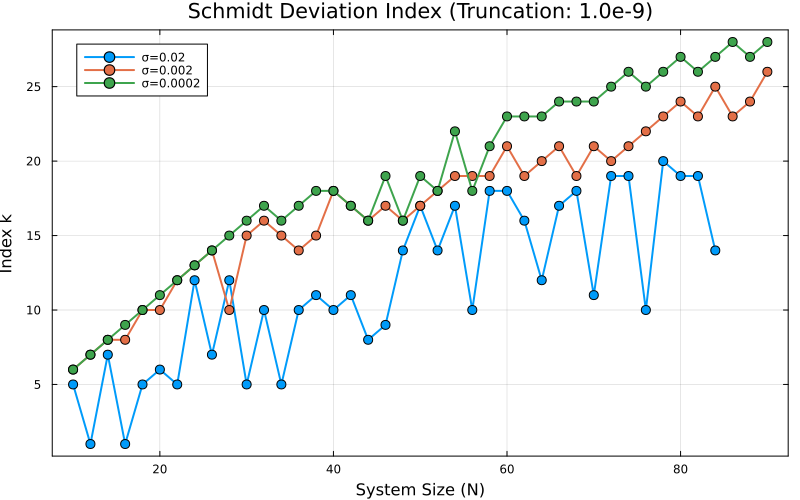

In [11]:
"""
Plots deviation indices for a specific truncation string using the pre-calculated global dictionary.
"""
function plot_deviation_index(all_deviations, chosen_cutoff)
    if !haskey(all_deviations, chosen_cutoff)
        error("Truncation $chosen_cutoff not found in pre-calculated dictionary.")
    end

    # Extract only the sigmas for this specific truncation
    target_data = all_deviations[chosen_cutoff]

    p = plot(
        title = "Schmidt Deviation Index (Truncation: $chosen_cutoff)",
        xlabel = "System Size (N)",
        ylabel = "Index k",
        framestyle = :box,
        grid = true,
        legend = :topleft,
        size = (800, 500)
    )
    
    # Sort sigmas for a consistent legend (descending)
    sigmas = sort(collect(keys(target_data)), rev=true)
    
    for σ in sigmas
        Ns = sort(collect(keys(target_data[σ])))
        indices = [target_data[σ][N] for N in Ns]
        
        plot!(p, Ns, indices, 
              label="σ=$σ", 
              marker=:circle, 
              markersize=5, 
              linewidth=2)
    end
    
    return p
end

chosen_cutoff = "1.0e-9"
p_dev = plot_deviation_index(deviation_indices, chosen_cutoff)
display(p_dev)

In [12]:
"""
Calculates tail weights and weight differences based on the deviation index.
Returns:
  1. tail_weights: Dict[cutoff][sigma][N] -> Σλ² (from k to end)
  2. normalised_tail_weights: Dict[cutoff][sigma][N] -> (Σλ²_tail / Σλ²_total)
  3. weight_diffs: Dict[cutoff][sigma][N] -> (W_head - W_tail)
"""
function calc_tail_weights(results_all::Dict, all_dev_indices::Dict)
    tail_weights = Dict()
    normalised_tails = Dict()
    weight_diffs = Dict()

    for (cutoff, sigma_devs) in all_dev_indices
        c_tail = Dict{Float64, Dict{Int, Float64}}()
        c_norm = Dict{Float64, Dict{Int, Float64}}()
        c_diff = Dict{Float64, Dict{Int, Float64}}()
        
        for (σ, n_devs) in sigma_devs
            n_tail = Dict{Int, Float64}()
            n_norm = Dict{Int, Float64}()
            n_diff = Dict{Int, Float64}()
            
            for (N, k) in n_devs
                coeffs = sort(results_all[cutoff][σ][N], rev=true)
                coeffs_sq = coeffs .^ 2
                w_total = sum(coeffs_sq)
                
                # Tail starts at index k; Head is everything before k
                if k <= length(coeffs_sq)
                    w_tail = sum(coeffs_sq[k:end])
                    w_head = (k > 1) ? sum(coeffs_sq[1:k-1]) : 0.0
                else
                    w_tail = 0.0
                    w_head = w_total
                end
                
                n_tail[N] = w_tail
                n_norm[N] = w_tail / w_total
                n_diff[N] = (w_head - w_tail) / w_total # Normalised difference
            end
            c_tail[σ] = n_tail
            c_norm[σ] = n_norm
            c_diff[σ] = n_diff
        end
        tail_weights[cutoff] = c_tail
        normalised_tails[cutoff] = c_norm
        weight_diffs[cutoff] = c_diff
    end
    
    return tail_weights, normalised_tails, weight_diffs
end


tail_weights, normalised_tails, weight_diffs = calc_tail_weights(results, deviation_indices)

(Dict{Any, Any}("1.0e-7" => Dict(0.002 => Dict(78 => 1.0488077050140732e-6, 56 => 2.025306768358079e-6, 16 => 0.0001554868014010342, 20 => 1.0831401587303894e-5, 58 => 2.3454556538835918e-7, 52 => 5.124865333699047e-7, 60 => 8.948512432813826e-8, 12 => 0.0010823224741919504, 24 => 3.6974993043890065e-7, 28 => 4.828784204733318e-6…), 0.2 => Dict(78 => 0.9999962009030873, 56 => 0.9999941378401873, 16 => 0.9999151690650181, 20 => 0.9999528198484311, 58 => 0.9999946786728682, 52 => 0.9999922706807496, 60 => 0.9999953994793839, 12 => 0.5670888351380842, 24 => 0.9999664302859863, 28 => 0.9999765769844962…), 0.02 => Dict(78 => 0.00013005060405604473, 56 => 0.015408818459757587, 16 => 0.9999988689910658, 20 => 0.02300963823943467, 58 => 0.0007853702099646861, 52 => 0.00022889557973488443, 60 => 0.0006498582601611409, 12 => 0.9999987419687266, 24 => 1.9541192281171516e-5, 28 => 1.9585560138852774e-5…), 0.0002 => Dict(78 => 1.0488889729470585e-6, 56 => 9.98108378980389e-7, 16 => 7.76933123666993

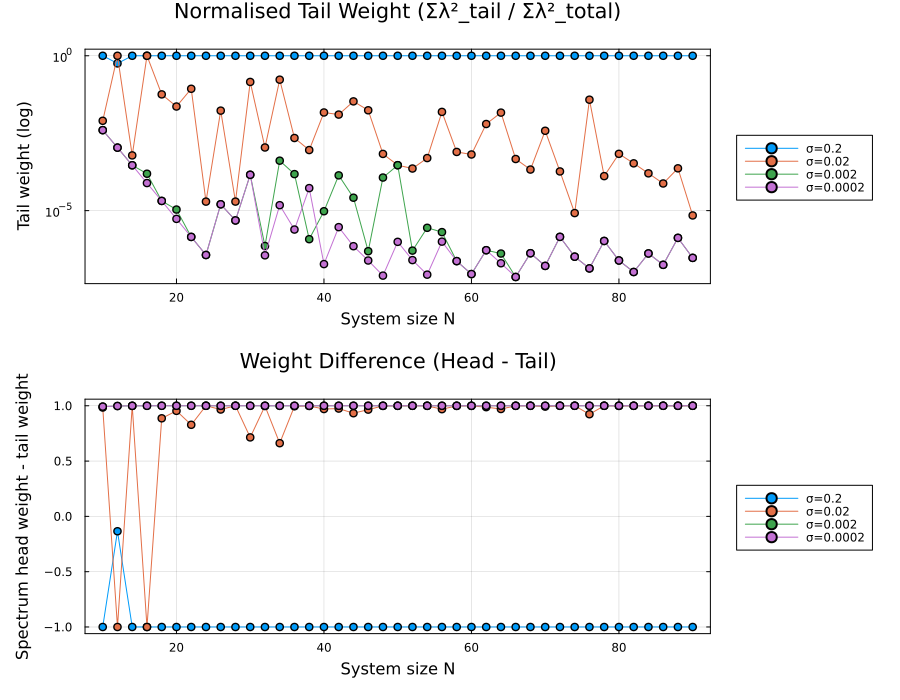

In [13]:
function plot_tail_weights(tail_data, norm_data, diff_data, chosen_cutoff; sigmas_to_plot=nothing)
    if !haskey(tail_data, chosen_cutoff)
        error("Cutoff $chosen_cutoff not found.")
    end

    # Normalised Tail Weight 
    p1 = plot(
        title = "Normalised Tail Weight (Σλ²_tail / Σλ²_total)",
        xlabel = "System size N", ylabel = "Tail weight (log)",
        yaxis = :log10, framestyle = :box, grid = true, legend = :outerright
    )

    # Weight Difference 
    p2 = plot(
        title = "Weight Difference (Head - Tail)",
        xlabel = "System size N", ylabel = "Spectrum head weight - tail weight",
        framestyle = :box, grid = true, legend = :outerright
    )

    available_sigmas = collect(keys(tail_data[chosen_cutoff]))
    sigmas = sigmas_to_plot === nothing ? 
             sort(available_sigmas, rev=true) : 
             sort([s for s in sigmas_to_plot if s in available_sigmas], rev=true)

    for σ in sigmas
        Ns = sort(collect(keys(tail_data[chosen_cutoff][σ])))
        nw = [norm_data[chosen_cutoff][σ][N] for N in Ns]
        wd = [diff_data[chosen_cutoff][σ][N] for N in Ns]

        plot!(p1, Ns, nw, label="σ=$σ", marker=:circle, markersize=4)
        plot!(p2, Ns, wd, label="σ=$σ", marker=:circle, markersize=4)
    end

    return plot(p1, p2, layout = (2, 1), size=(900, 700), margin=5Plots.mm)
end

p_tails = plot_tail_weights(tail_weights, normalised_tails, weight_diffs, "1.0e-7")
display(p_tails)

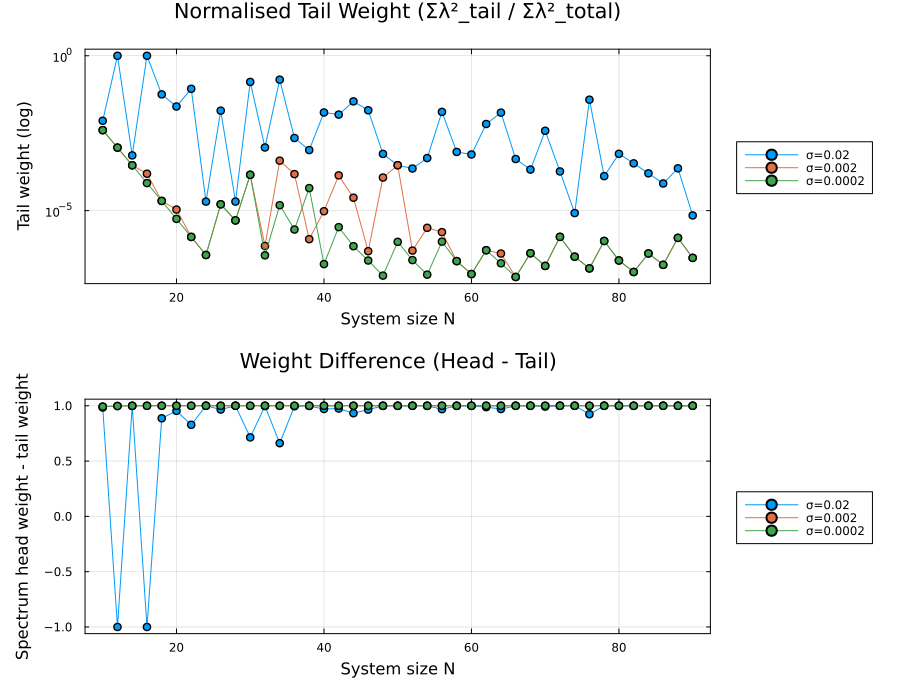

In [14]:
# Create a list excluding 0.2
filtered_sigmas = [s for s in sigma_list if s != 0.2]
p_tails = plot_tail_weights(tail_weights, normalised_tails, weight_diffs, "1.0e-7", sigmas_to_plot=filtered_sigmas)
display(p_tails)

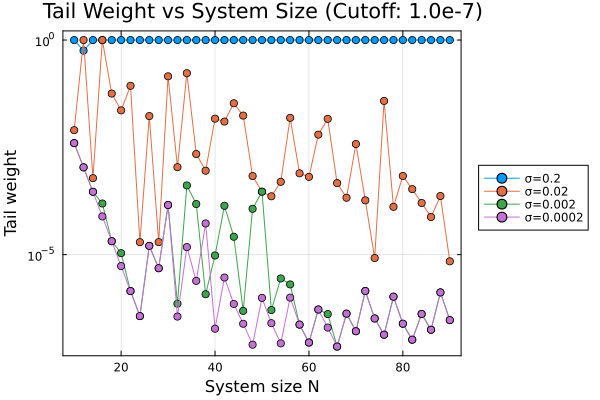

In [15]:
function plot_weight_of_tail(tail_data, chosen_cutoff; sigmas_to_plot=nothing)
    if !haskey(tail_data, chosen_cutoff)
        error("Cutoff $chosen_cutoff not found.")
    end

    p1 = plot(
        title = "Tail Weight vs System Size (Cutoff: $chosen_cutoff)",
        xlabel = "System size N", 
        ylabel = "Tail weight",
        framestyle = :box, 
        grid = true, 
        legend = :outerright,
        yaxis = :log 
    )

    available_sigmas = collect(keys(tail_data[chosen_cutoff]))
    sigmas = sigmas_to_plot === nothing ? 
              sort(available_sigmas, rev=true) : 
              sort([s for s in sigmas_to_plot if s in available_sigmas], rev=true)

    for σ in sigmas
        Ns = sort(collect(keys(tail_data[chosen_cutoff][σ])))
        
        tw = [tail_data[chosen_cutoff][σ][N] for N in Ns]

        plot!(p1, Ns, tw, label="σ=$σ", marker=:circle, markersize=4)
    end

    return p1
end

p_tails = plot_weight_of_tail(tail_weights, "1.0e-7")
display(p_tails)

In [16]:
function get_all_spectrum_heads(full_results)
    all_heads_dict = Dict()
    
    for cutoff_str in keys(full_results)
        threshold = parse(Float64, cutoff_str)
        all_heads_dict[cutoff_str] = Dict()
        
        sigma_data = full_results[cutoff_str]
        
        for sigma in keys(sigma_data)
            all_heads_dict[cutoff_str][sigma] = Dict()
            
            for N in keys(sigma_data[sigma])
                spectrum = sigma_data[sigma][N]
                head_spectrum = [val for val in spectrum if val >= threshold]
                
                all_heads_dict[cutoff_str][sigma][N] = head_spectrum
            end
        end
    end
    
    return all_heads_dict
end

head_data = get_all_spectrum_heads(results)
tali_data = tail_weights

Dict{Any, Any} with 11 entries:
  "1.0e-7"  => Dict(0.002=>Dict(78=>1.04881e-6, 56=>2.02531e-6, 16=>0.000155487…
  "1.0e-6"  => Dict(0.002=>Dict(78=>3.92423e-6, 56=>1.30517e-5, 16=>0.000155487…
  "1.0e-4"  => Dict(0.002=>Dict(78=>0.000235215, 56=>0.000237773, 16=>0.0047653…
  "1.0e-13" => Dict(0.0002=>Dict(56=>2.49615e-9, 16=>7.76958e-5, 20=>5.41513e-6…
  "1.0e-10" => Dict(0.002=>Dict(78=>1.94433e-6, 56=>3.13171e-7, 16=>0.00015573,…
  "1.0e-12" => Dict(0.002=>Dict(56=>2.55604e-7, 16=>0.000155731, 20=>1.10822e-5…
  "1.0e-8"  => Dict(0.002=>Dict(78=>1.76632e-6, 56=>2.47553e-6, 16=>0.000155487…
  "1.0e-9"  => Dict(0.002=>Dict(78=>2.74662e-7, 56=>1.35556e-6, 16=>0.000155714…
  "1.0e-14" => Dict(0.0002=>Dict(16=>7.76958e-5, 20=>5.41513e-6, 12=>0.00108222…
  "1.0e-5"  => Dict(0.002=>Dict(78=>1.97959e-5, 56=>0.000100899, 16=>0.00015548…
  "1.0e-11" => Dict(0.002=>Dict(78=>5.32814e-7, 56=>2.52172e-7, 16=>0.000155731…

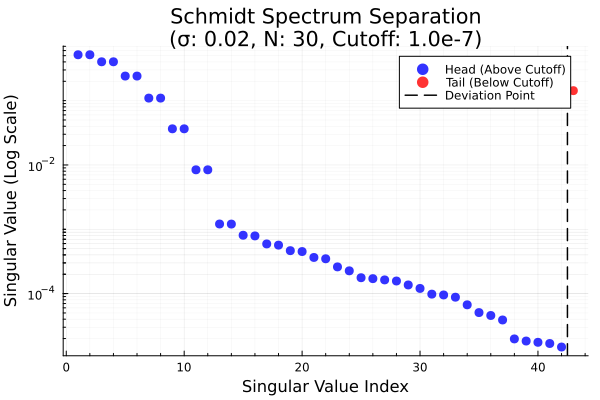

In [17]:
using Plots

function plot_schmidt_spectrum(head_data, tail_data, cutoff_str, sigma, N)

    sigma_key = sigma
    n_key = N
    sample_sigma_key = first(keys(head_data[cutoff_str]))
    if typeof(sample_sigma_key) != typeof(sigma)
        sigma_key = (typeof(sample_sigma_key) == String) ? string(sigma) : sigma
    end
    sample_n_key = first(keys(head_data[cutoff_str][sigma_key]))
    if typeof(sample_n_key) != typeof(N)
        n_key = (typeof(sample_n_key) == String) ? string(N) : N
    end

    head = vec([head_data[cutoff_str][sigma_key][n_key]...])
    tail = vec([tail_data[cutoff_str][sigma_key][n_key]...])
    

    head_indices = 1:length(head)
    tail_indices = (length(head) + 1):(length(head) + length(tail))
    
    p = plot(title="Schmidt Spectrum Separation\n(σ: $sigma, N: $N, Cutoff: $cutoff_str)",
             xlabel="Singular Value Index", 
             ylabel="Singular Value (Log Scale)",
             yscale=:log10, 
             legend=:topright,
             grid=true,
             minorgrid=true)
    
    # Plot the Head 
    if !isempty(head)
        scatter!(p, head_indices, head, 
                 label="Head (Above Cutoff)", 
                 mc=:blue, ms=5, ma=0.8, markerstrokewidth=0)
    end
    
    # Plot the Tail 
    if !isempty(tail)
        scatter!(p, tail_indices, tail, 
                 label="Tail (Below Cutoff)", 
                 mc=:red, ms=5, ma=0.8, markerstrokewidth=0)
    end
    

    separation_index = length(head) + 0.5
    vline!(p, [separation_index], 
           line=(:black, :dash, 1.5), 
           label="Deviation Point")

    return p
end

p = plot_schmidt_spectrum(head_data, tali_data, "1.0e-7", 0.02, 30)
display(p)

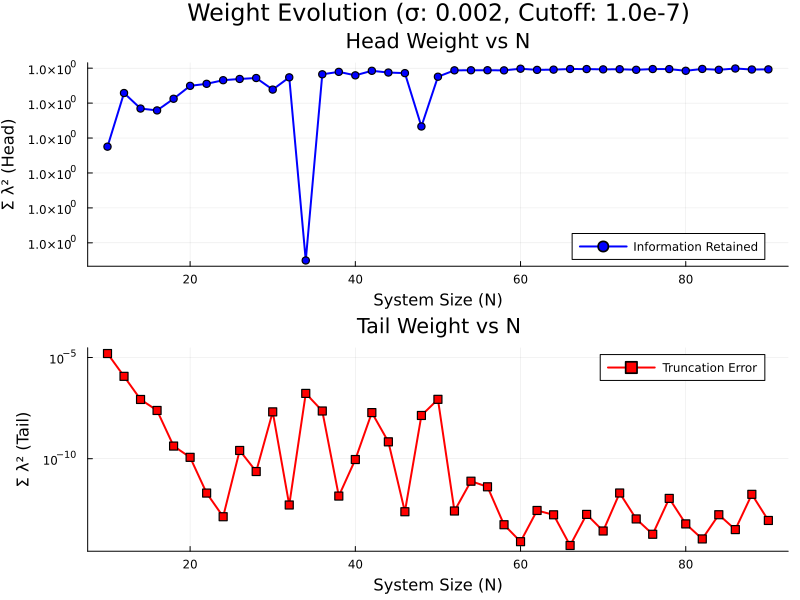

In [18]:
using Plots

function plot_weight_evolution_separate(head_data, tail_data, cutoff_str, sigma)
    sigma_key = sigma
    sample_sigma_key = first(keys(head_data[cutoff_str]))
    if typeof(sample_sigma_key) != typeof(sigma)
        sigma_key = (typeof(sample_sigma_key) == String) ? string(sigma) : sigma
    end

    n_keys = collect(keys(head_data[cutoff_str][sigma_key]))
    n_values_numeric = sort([typeof(k) == String ? parse(Int, k) : k for k in n_keys])
    
    head_weights = Float64[]
    tail_weights = Float64[]
    
    for n in n_values_numeric
        n_key = (typeof(first(n_keys)) == String) ? string(n) : n
        
        h_spec = vec([head_data[cutoff_str][sigma_key][n_key]...])
        t_spec = vec([tail_data[cutoff_str][sigma_key][n_key]...])
        
        push!(head_weights, sum(h_spec .^ 2))
        push!(tail_weights, sum(t_spec .^ 2))
    end
    

    p1 = plot(n_values_numeric, head_weights,
              title="Head Weight vs N",
              ylabel="Σ λ² (Head)",
              xlabel="System Size (N)",
              lc=:blue, lw=2, marker=:circle, mc=:blue,
              label="Information Retained",
              grid=true)


    p2 = plot(n_values_numeric, tail_weights,
              title="Tail Weight vs N",
              ylabel="Σ λ² (Tail)",
              xlabel="System Size (N)",
              lc=:red, lw=2, marker=:square, mc=:red,
              label="Truncation Error",
              yscale=:log10,
              grid=true)
    
    final_plot = plot(p1, p2, layout=(2, 1), size=(800, 600), 
                      plot_title="Weight Evolution (σ: $sigma, Cutoff: $cutoff_str)")
    
    return final_plot
end

p_weight = plot_weight_evolution_separate(head_data, tali_data, "1.0e-7", 0.002)
display(p_weight)